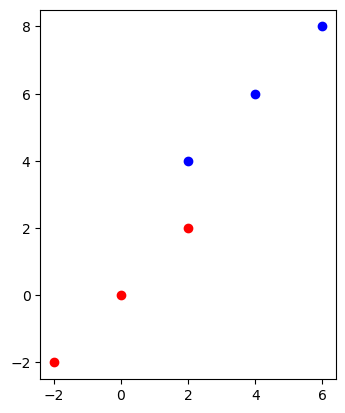

In [ ]:
# 원본데이터 -> 평균제거 -> pca적용 -> 변환된 데이터
# 각 feature의 평균을 빼서 데이터의 중심을 원점

import matplotlib.pyplot as plt
import numpy as np

ax = plt.subplot(1,1,1, aspect='equal')
x = np.array([[2,4], [4,6], [6,8]])
ax.scatter(x[:,0], x[:,1], color='blue')
x -= x.mean(axis=0).astype(int)
ax.scatter(x[:,0], x[:,1], color='red')

Text(0.5, 1.0, 'PCA')

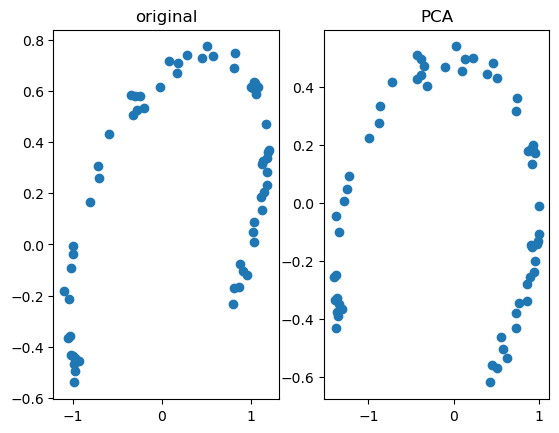

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

m = 60
# 3차원 데이터
w1, w2 = 0.1, 0.3
noise = 0.1

angle = np.random.rand(m) * 3 * np.pi / 2 - 0.5

x = np.empty((m,3))

# 서로 약간 상관관계 있는 구조
x[:,0] = np.cos(angle) + np.sin(angle)/2 + noise * np.random.rand(m)
x[:,1] = np.sin(angle) * 0.7 + noise * np.random.rand(m)
x[:,2] = x[:,0] * w1  + x[:,1] * w2 + noise * np.random.rand(m)

from sklearn.decomposition import PCA
# PCA
pca = PCA(n_components=2)
x2D = pca.fit_transform(x)

# 변환 전 (x의 일부 차원만 시각화)
plt.subplot(1,2,1)
plt.scatter(x[:,0], x[:,1])
plt.title('original')

# 변환 후
plt.subplot(1,2,2)
plt.scatter(x2D[:,0], x2D[:,1])
plt.title('PCA')

Text(0.5, 1.0, 'PCA')

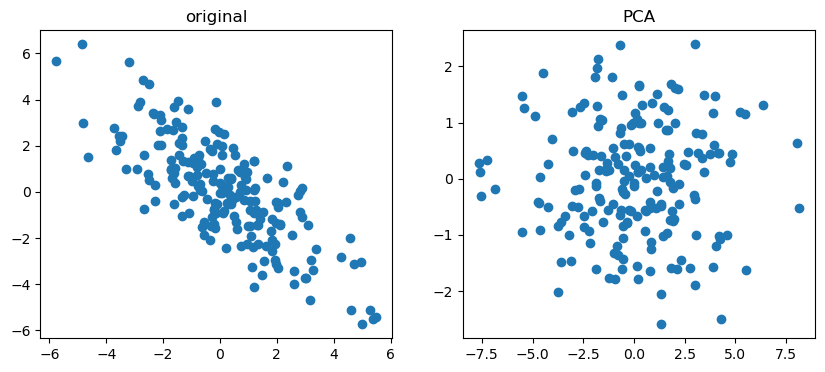

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
# 타원형 데이터 생성
m = 200
# 길게 늘어진 직선 형태
x = np.random.randn(m,2)
x[:,0] *= 3
# 회전 (기울기)
theta = np.pi / 4 
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

x = x@rotation_matrix
# PCA 적용
pca = PCA(n_components=2)
x2D = pca.fit_transform(x)

fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].scatter(x[:,0], x[:,1])
ax[0].set_title('original')

ax[1].scatter(x2D[:,0], x2D[:,1])
ax[1].set_title('PCA')

In [ ]:
# 내가 작성한 코드

# wine 데이터셋
from sklearn.datasets import load_wine
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

wine = load_wine(as_frame=True)

x = wine.data
y = wine.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# for i in range(5):
#     x_train, x_test, y_train, y_test = train_test_split(
#         x, y, test_size=0.2, random_state=i
#     )

# 데이터 + 모델 조합 -> 성능 측정
nomal_model = make_pipeline(
    (StandardScaler()),
    (SVC(C=1, random_state=42))
)
nomal_model.fit(x_train, y_train)
nomal_pred = nomal_model.predict(x_test)
# 데이터(pca변환) + 모델 조합 -> 성능 측정
pca_model = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    SVC(C=1, random_state=42)
)

pca_model.fit(x_train, y_train)
pca_pred = pca_model.predict(x_test)

print(classification_report(y_test, nomal_pred), classification_report(y_test, pca_pred))

# 교차검증
nomal_score = cross_val_predict(nomal_model, x, y, cv=5)
pca_score = cross_val_predict(pca_model, x, y, cv=5)
print(nomal_score.mean(), pca_score.mean())


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

0.9438202247191011 0.9325842696629213


In [ ]:
# 강사님 코드

# win 데이터셋
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)

#데이터 + 모델 조합  성능측정
#데이터(PCA변환) + 모델 조합  성능측정
X = wine.data
y = wine.target

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=2)),
])
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier,BaggingClassifier,StackingClassifier
from sklearn.model_selection import StratifiedKFold

# random
models = {'sgd':SGDClassifier(random_state=42), 
          'randomF':RandomForestClassifier(random_state=42),
          'tree':DecisionTreeClassifier(random_state=42)
          }

for model_name,model in models.items():    
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    fold = StratifiedKFold(shuffle=True,random_state=42)
    y_predict = cross_val_predict(model,X_scaled,y,cv=fold)
    print(model_name)
    print(classification_report(y,y_predict))

In [ ]:
# voting
voting = VotingClassifier([
    ('sgd', SGDClassifier(random_state=42, loss='log_loss')), 
    ('randomF', RandomForestClassifier(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42))
], voting='hard'
)
y_predict = cross_val_predict(voting, X_scaled, y, cv=fold)
print(classification_report(y, y_predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        59
           1       0.97      0.96      0.96        71
           2       0.96      0.98      0.97        48

    accuracy                           0.97       178
   macro avg       0.97      0.97      0.97       178
weighted avg       0.97      0.97      0.97       178



In [ ]:
# bagging
bagging = BaggingClassifier(voting, n_estimators=10, random_state=42
)
y_predict = cross_val_predict(bagging, X_scaled, y, cv=fold)
print(classification_report(y, y_predict))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        59
           1       1.00      0.97      0.99        71
           2       0.98      1.00      0.99        48

    accuracy                           0.99       178
   macro avg       0.99      0.99      0.99       178
weighted avg       0.99      0.99      0.99       178



In [ ]:
from sklearn.linear_model import LogisticRegression

# staking
stacking = StackingClassifier([
    ('sgd', SGDClassifier(random_state=42, loss='log_loss')), 
    ('randomF', RandomForestClassifier(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42))
],final_estimator=LogisticRegression(random_state=42)
)
y_predict = cross_val_predict(stacking, X_scaled, y, cv=fold)
print(classification_report(y, y_predict))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        59
           1       0.97      0.97      0.97        71
           2       0.98      0.96      0.97        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178



In [ ]:
# staking - pca 

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=10)),
])
x_pipeline = pipeline.fit_transform(x)
stacking = StackingClassifier([
    ('sgd', SGDClassifier(random_state=42, loss='log_loss')), 
    ('randomF', RandomForestClassifier(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42))
],final_estimator=LogisticRegression(random_state=42)
)
y_predict = cross_val_predict(stacking, x_pipeline, y, cv=fold)
print(classification_report(y, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.97      0.97        71
           2       0.96      0.96      0.96        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178



In [ ]:
# n_compents 찾기 -> 누적분산

import numpy as np
pca = PCA(n_components=10)
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
custom_variable = np.cumsum(
    pca.explained_variance_ratio_
)
print(custom_variable) # 99% 이상이면 정보보존이 중요 / 95% 이상이면 좋음 / 90% 이상이면 빠르게

np.argmax(custom_variable >= 0.95) + 1

[0.32853032 0.52534437 0.65218765 0.73007254 0.79975362 0.85582868
 0.90392525 0.92934163 0.9502528  0.96780032]


np.int64(9)

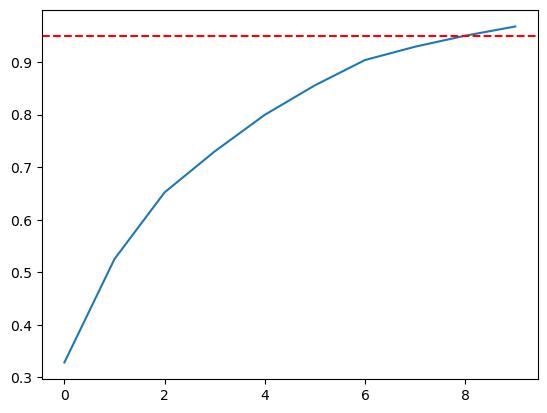

In [ ]:
# 시각적 엘보우 : 급격히 증가 후 완만해지는 구간
import matplotlib.pyplot as plt

plt.plot(custom_variable)
plt.axhline(y=0.95, linestyle='--', c='red')

In [ ]:
# 자동으로 찾기
# n_compents 찾기 -> 누적분산

pca = PCA(n_components=0.95) # 95% 분산을 설명하는 최소 component 자동 선택
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
print(pca.n_components)

0.95


In [ ]:
# 시각화
